In [ ]:
import sys
import subprocess
required_packages = [
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "requests"
]
for package in required_packages:
  subprocess.run(
      [sys.executable,"-m","pip","install","-q","--break-sysytem-packages",package]
  )

print("All required packages are installed!!!")

All required packages are installed!!!


In [ ]:
import pandas as pd
DATA_URL = "https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv"
salary_df = pd.read_csv(DATA_URL)
salary_df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
print("Shape of dataset (rows, columns):", salary_df.shape)
print()
print("Data types of each column:")
print(salary_df.dtypes)

Shape of dataset (rows, columns): (30, 2)

Data types of each column:
YearsExperience    float64
Salary             float64
dtype: object


In [ ]:
missing_values_per_column = salary_df.isnull().sum()
print("Missing values per column: ")
print(missing_values_per_column)

Missing values per column: 
YearsExperience    0
Salary             0
dtype: int64


In [ ]:
salary_df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


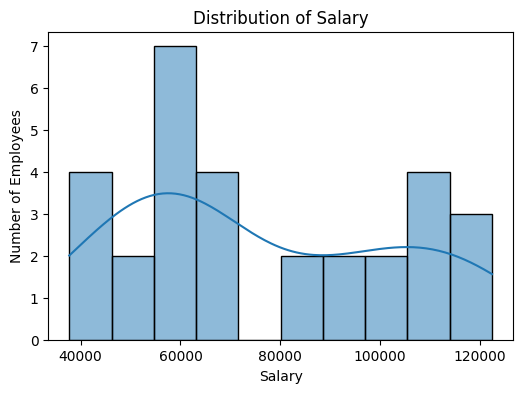

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.histplot(salary_df["Salary"],bins=10,kde=True)
plt.title("Distribution of Salary")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

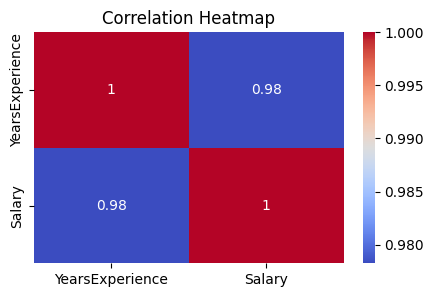

In [ ]:
plt.figure(figsize=(5,3))
correlation_matrix = salary_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

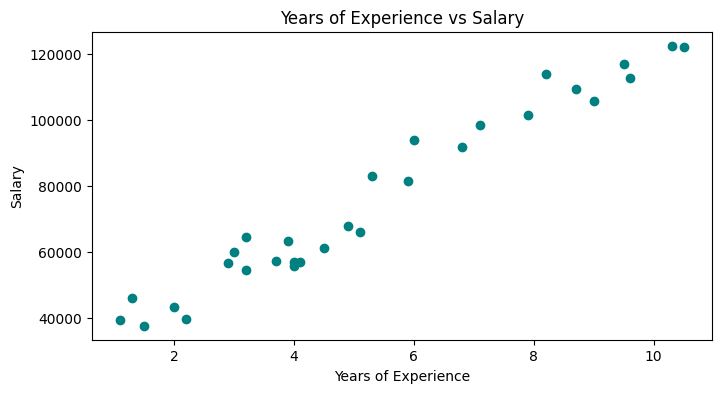

In [ ]:
plt.figure(figsize=(8,4))
plt.scatter(salary_df["YearsExperience"], salary_df["Salary"], color="teal")
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Example: hours studied vs marks scored
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([2, 4, 5, 4, 5, 7, 8, 9, 10, 12])

# Put it in a DataFrame just to view it nicely
df = pd.DataFrame({'Hours': X.flatten(), 'Marks': y})
df

,Hours,Marks
0,1,2
1,2,4
2,3,5
3,4,4
4,5,5
5,6,7
6,7,8
7,8,9
8,9,10
9,10,12


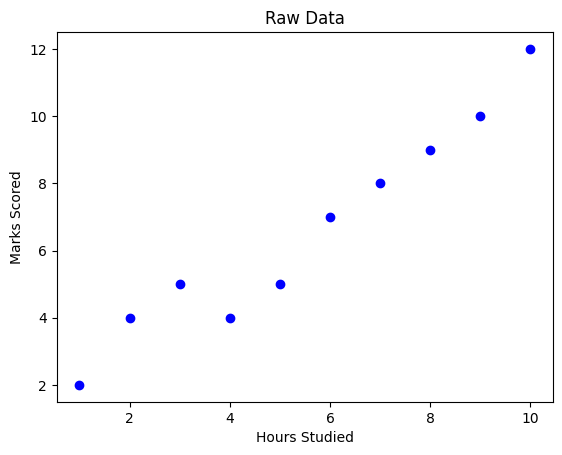

In [ ]:
plt.scatter(X, y, color='blue')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Scored')
plt.title('Raw Data')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 8
Test size: 2


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)

Slope (m): 1.0689655172413794
Intercept (c): 0.6206896551724128


In [ ]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison

,Actual,Predicted
0,10,10.241379
1,4,2.758621


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 0.7996432818073731
R² Score: 0.9111507464658475


In [ ]:
plt.scatter(X, y, color='blue', label='Actual data')
plt.plot(X, model.predict(X), color='red', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Scored')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

In [ ]:
new_hours = np.array([[11]])
predicted_marks = model.predict(new_hours)
print(f"Predicted marks for 11 hours studied: {predicted_marks[0]:.2f}")

Predicted marks for 11 hours studied: 12.38


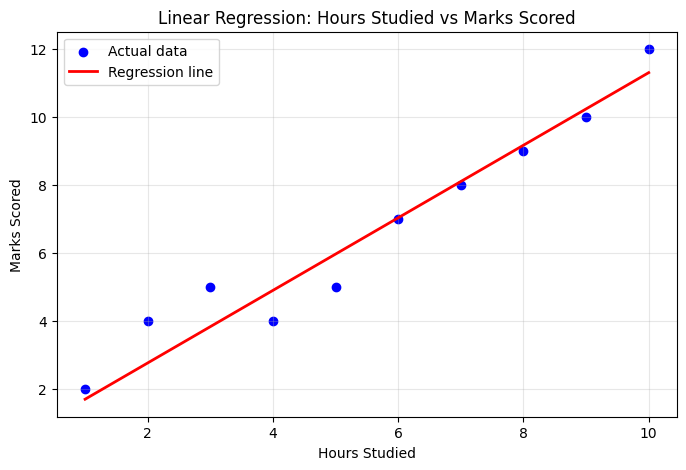

In [ ]:
plt.figure(figsize=(8, 5))

# Actual data points
plt.scatter(X, y, color='blue', label='Actual data')

# Regression line
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression line')

# Labels and styling
plt.xlabel('Hours Studied')
plt.ylabel('Marks Scored')
plt.title('Linear Regression: Hours Studied vs Marks Scored')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()